<a href="https://colab.research.google.com/github/mmetee/python_2026/blob/main/SDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_386/2825709458.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(list(tickers.values()), period="1y")['Close']
[*********************100%***********************]  8 of 8 completed


Asset      | Current Price | Drift (mu) | Vol (sigma)
-------------------------------------------------------
Gold       |      5181.30 |     36.78% |     25.60%
Silver     |        84.69 |     33.81% |     64.12%
Oil        |        91.27 |     40.49% |     36.81%
NVDA       |       177.82 |     22.13% |     43.58%
Google     |       298.52 |     39.20% |     30.17%
EUR/USD    |         1.16 |      4.26% |      7.61%
GBP/USD    |         1.34 |      4.55% |      6.92%
BTC        |     68286.84 |    -14.06% |     37.46%


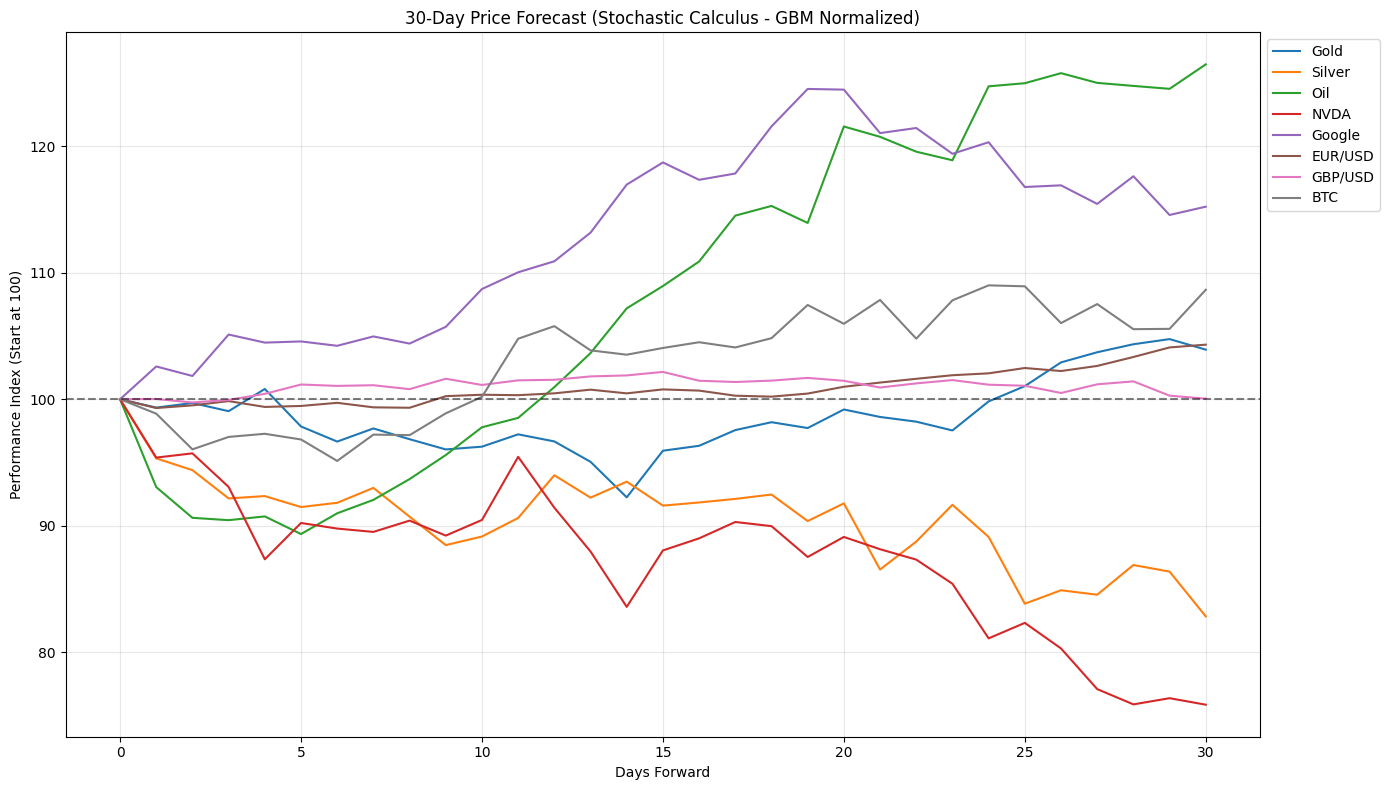

In [7]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. กำหนดรายชื่อสินทรัพย์ (Ticker จาก Yahoo Finance)
tickers = {
    'Gold': 'GC=F',
    'Silver': 'SI=F',
    'Oil': 'CL=F',
    'NVDA': 'NVDA',
    'Google': 'GOOGL',
    'EUR/USD': 'EURUSD=X',
    'GBP/USD': 'GBPUSD=X',
    'BTC': 'BTC-USD'
}

# 2. ดึงข้อมูลย้อนหลัง 1 ปี
data = yf.download(list(tickers.values()), period="1y")['Close']

# 3. คำนวณ Annualized Drift (mu) และ Volatility (sigma)
returns = np.log(data / data.shift(1))
mu = returns.mean() * 252       # ค่าเฉลี่ยผลตอบแทนต่อปี
sigma = returns.std() * np.sqrt(252)  # ความผันผวนต่อปี

# 4. ฟังก์ชันพยากรณ์ราคา (GBM)
def forecast_gbm(s0, mu, sigma, days=30):
    dt = 1/252
    t = np.arange(1, days + 1)
    # ใช้ Random แบบ Vectorized เพื่อความเร็ว
    W = np.random.standard_normal(days)
    W = np.cumsum(W) * np.sqrt(dt)
    S = s0 * np.exp((mu - 0.5 * sigma**2) * (t * dt) + sigma * W)
    return S

# 5. แสดงผลและจำลองภาพ
plt.figure(figsize=(14, 8))
print(f"{'Asset':<10} | {'Current Price':<12} | {'Drift (mu)':<10} | {'Vol (sigma)':<10}")
print("-" * 55)

for name, ticker in tickers.items():
    s0 = data[ticker].dropna().iloc[-1] # ราคาสุดท้ายปัจจุบัน (ใช้ค่าที่ไม่ใช่ NaN)
    m = mu[ticker]
    s = sigma[ticker]

    print(f"{name:<10} | {s0:>12.2f} | {m:>10.2%} | {s:>10.2%}")

    # พยากรณ์ไปข้างหน้า 30 วันทำการ
    future_prices = forecast_gbm(s0, m, s, days=30)

    # ทำ Normalize เพื่อเทียบ Performance (เริ่มที่ 100)
    plt.plot(np.append(100, (future_prices / s0) * 100), label=name)

plt.axhline(100, color='black', linestyle='--', alpha=0.5)
plt.title("30-Day Price Forecast (Stochastic Calculus - GBM Normalized)")
plt.xlabel("Days Forward")
plt.ylabel("Performance Index (Start at 100)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# 1. ตรวจสอบและดึงข้อมูลใหม่พร้อมลบค่าว่าง
# ใช้ group_by=False เพื่อให้จัดการง่ายขึ้น
raw_data = yf.download(list(tickers.values()), period="1y")['Close']

# 2. แก้ปัญหา nan โดยการ Fill ข้อมูลที่ขาดหาย หรือ Drop ออก
# สินค้าโภคภัณฑ์และหุ้นมีวันหยุดต่างกัน ทำให้เกิดช่องว่างใน DataFrame รวม
data = raw_data.ffill().dropna()

# 3. คำนวณ Returns โดยระบุเจาะจงรายตัวเพื่อป้องกัน error
returns = np.log(data / data.shift(1)).dropna()

mu = returns.mean() * 252
sigma = returns.std() * np.sqrt(252)

# เช็คค่า mu อีกรอบว่ามีตัวไหนเป็น nan ไหม
print("Check mu values:\n", mu)


/tmp/ipykernel_386/3850040244.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(list(tickers.values()), period="1y")['Close']
[*********************100%***********************]  8 of 8 completed

Check mu values:
 Ticker
BTC-USD    -0.165716
CL=F        0.213014
EURUSD=X    0.050587
GBPUSD=X    0.024842
GC=F        0.399559
GOOGL       0.375926
NVDA        0.315107
SI=F        0.660268
dtype: float64


In [29]:

def calculate_mc_var(s0, mu, sigma, days=30, simulations=10000, confidence_level=0.95):
    dt = 1/252
    # จำลองราคาปลายทาง 10,000 รูปแบบพร้อมกัน (Vectorized)
    Z = np.random.standard_normal(simulations)
    # สูตร GBM ณ เวลา T
    ST = s0 * np.exp((mu - 0.5 * sigma**2) * (days * dt) + sigma * np.sqrt(days * dt) * Z)

    # คำนวณกำไร/ขาดทุนเป็นเปอร์เซ็นต์
    pnl_pct = (ST - s0) / s0

    # หาค่า Percentile ที่ (1 - confidence_level) เช่น 0.05 สำหรับ 95% Confidence
    var_pct = np.percentile(pnl_pct, (1 - confidence_level) * 100)
    return var_pct

# กำหนดค่า tickers กลับเป็น dictionary เพื่อป้องกัน AttributeError
tickers_dict = {
    'Gold': 'GC=F',
    'Silver': 'SI=F',
    'Oil': 'CL=F',
    'NVDA': 'NVDA',
    'Google': 'GOOGL',
    'EUR/USD': 'EURUSD=X',
    'GBP/USD': 'GBPUSD=X',
    'BTC': 'BTC-USD'
}

print(f"{'Asset':<10} | {'30D Var (95%)':<15} | {'Worst Case Scenario (30 Days)'}")
print("-" * 65)

for name, ticker in tickers_dict.items():
    s0 = data[ticker].iloc[-1]
    m = mu[ticker]
    s = sigma[ticker]

    var_95 = calculate_mc_var(s0, m, s, days=30, simulations=10000)
    worst_case_price = s0 * (1 + var_95)

    print(f"{name:<10} | {var_95:>14.2%} | Price could drop to {worst_case_price:,.2f}")


Asset      | 30D Var (95%)   | Worst Case Scenario (30 Days)
-----------------------------------------------------------------
Gold       |         -7.72% | Price could drop to 4,781.09
Silver     |        -21.08% | Price could drop to 66.84
Oil        |        -14.08% | Price could drop to 78.42
NVDA       |        -15.71% | Price could drop to 149.88
Google     |        -10.01% | Price could drop to 268.63
EUR/USD    |         -2.94% | Price could drop to 1.13
GBP/USD    |         -3.01% | Price could drop to 1.30
BTC        |        -21.62% | Price could drop to 53,373.09


In [28]:


# 1. โหลดข้อมูลและจัดการค่า NaN ให้เรียบร้อย
tickers = {'Gold':'GC=F', 'Silver':'SI=F', 'Oil':'CL=F', 'NVDA':'NVDA',
           'Google':'GOOGL', 'EUR/USD':'EURUSD=X', 'GBP/USD':'GBPUSD=X', 'BTC':'BTC-USD'}

raw_data = yf.download(list(tickers.values()), period="1y")['Close']
data = raw_data.ffill().dropna() # เติมค่าว่างด้วยราคาวันก่อนหน้า

# 2. คำนวณค่าทางสถิติ
returns = np.log(data / data.shift(1)).dropna()
mu = returns.mean() * 252
sigma = returns.std() * np.sqrt(252)

def calculate_var_and_es(s0, mu, sigma, days=30, simulations=100000, conf_level=0.95):
    dt = days/252
    # Monte Carlo Simulation (Vectorized)
    Z = np.random.standard_normal(simulations)
    ST = s0 * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    pnl_pct = (ST - s0) / s0

    # 3. คำนวณ Value at Risk (VaR)
    var_threshold = np.percentile(pnl_pct, (1 - conf_level) * 100)

    # 4. คำนวณ Expected Shortfall (ES)
    # หาค่าเฉลี่ยของ Returns ที่แย่กว่าค่า VaR
    tail_losses = pnl_pct[pnl_pct <= var_threshold]
    es_pct = tail_losses.mean()

    return var_threshold, es_pct

print(f"{'Asset':<10} | {'30D VaR (95%)':<14} | {'30D ES (Tail Risk)':<18}")
print("-" * 50)

for name, ticker in tickers.items():
    v, es = calculate_var_and_es(data[ticker].iloc[-1], mu[ticker], sigma[ticker])
    print(f"{name:<10} | {v:>13.2%} | {es:>17.2%}")


/tmp/ipykernel_386/1737246478.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(list(tickers.values()), period="1y")['Close']
[*********************100%***********************]  8 of 8 completed


Asset      | 30D VaR (95%)  | 30D ES (Tail Risk)
--------------------------------------------------
Gold       |        -7.70% |           -10.52%
Silver     |       -21.06% |           -26.70%
Oil        |       -14.08% |           -17.63%
NVDA       |       -15.32% |           -19.34%
Google     |        -9.81% |           -12.99%
EUR/USD    |        -2.93% |            -3.80%
GBP/USD    |        -3.01% |            -3.83%
BTC        |       -21.35% |           -25.43%


In [9]:
# คำนวณ Kelly Criterion (Optimal f)
# สูตร: f = mu / sigma^2
# เราจะใช้ค่า mu และ sigma ที่คำนวณไว้ก่อนหน้านี้

print(f"{'Asset':<10} | {'Drift (Annl.)':<14} | {'ES (Tail)':<12} | {'Kelly %':<10} | {'Half-Kelly (Safe)'}")
print("-" * 75)

kelly_results = []

for name, ticker in tickers.items():
    m = mu[ticker]
    s = sigma[ticker]
    _, es = calculate_var_and_es(data[ticker].iloc[-1], m, s)

    # Kelly Fraction (f*)
    # หาก m ติดลบ Kelly จะบอกให้ลง 0 (ไม่ควรเทรดฝั่ง Long)
    k_fraction = max(0, m / s**2)

    # Fractional Kelly (มักใช้ 0.5 เพื่อความปลอดภัยจากโมเดลคลาดเคลื่อน)
    safe_kelly = k_fraction * 0.5

    print(f"{name:<10} | {m:>13.2%} | {es:>11.2%} | {k_fraction:>9.1%} | {safe_kelly:>10.1%}")

# ข้อแนะนำ: หากค่า Kelly % สูงเกิน 100% (เช่น NVDA)
# หมายความว่าตามทฤษฎีคุณควรใช้ Leverage แต่ในความจริงควร Limit ไว้ที่ Risk Limit ของพอร์ตครับ


Asset      | Drift (Annl.)  | ES (Tail)    | Kelly %    | Half-Kelly (Safe)
---------------------------------------------------------------------------
Gold       |        39.96% |     -10.69% |    825.9% |     412.9%
Silver     |        66.03% |     -26.50% |    240.4% |     120.2%
Oil        |        21.30% |     -17.60% |    233.5% |     116.8%
NVDA       |        31.51% |     -19.34% |    261.4% |     130.7%
Google     |        37.59% |     -13.00% |    580.5% |     290.3%
EUR/USD    |         5.06% |      -3.83% |   1287.4% |     643.7%
GBP/USD    |         2.48% |      -3.83% |    716.9% |     358.4%
BTC        |       -16.52% |     -25.53% |      0.0% |       0.0%


/tmp/ipykernel_386/4265243539.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers_list, period="2y")['Close'].ffill()
[*********************100%***********************]  8 of 8 completed


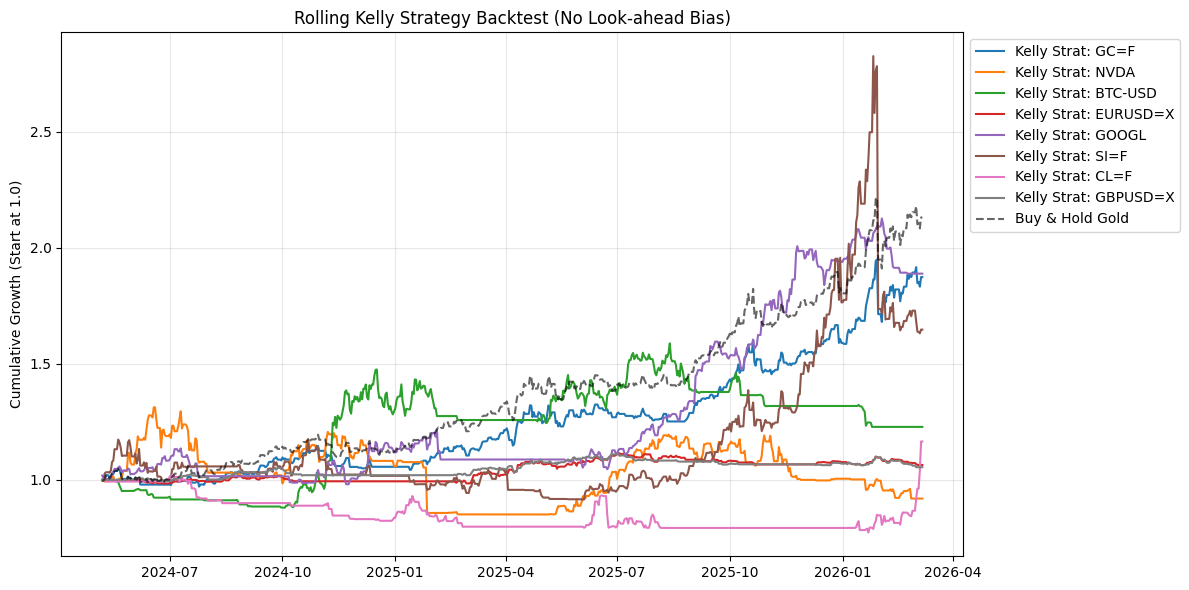

In [30]:


# 1. ดึงข้อมูลย้อนหลัง 2 ปี (เพื่อให้มี Window สำหรับคำนวณช่วงแรก)
# Update tickers_list to include all assets from all_assets in the next cell
tickers_list = ['GC=F', 'NVDA', 'BTC-USD', 'EURUSD=X', 'GOOGL', 'SI=F', 'CL=F', 'GBPUSD=X']
data = yf.download(tickers_list, period="2y")['Close'].ffill()
returns = np.log(data / data.shift(1)).dropna()

# 2. ตั้งค่า Rolling Window
window = 60 # ใช้ข้อมูล 60 วันย้อนหลังเพื่อทำนายวันพรุ่งนี้
portfolio_returns = pd.DataFrame(index=returns.index[window:])

for ticker in tickers_list:
    asset_returns = returns[ticker]
    strat_returns = []

    for i in range(window, len(asset_returns)):
        # หั่นข้อมูลย้อนหลัง 60 วัน (Rolling)
        past_returns = asset_returns.iloc[i-window:i]

        # คำนวณ Mu และ Sigma (Annualized)
        mu_rolling = past_returns.mean() * 252
        sigma_rolling = past_returns.std() * np.sqrt(252)

        # คำนวณ Half-Kelly (จำกัดไม่ให้เกิน 100% เพื่อความสมจริง)
        if sigma_rolling > 0:
            kelly_f = max(0, mu_rolling / (sigma_rolling**2)) * 0.5
            kelly_f = min(kelly_f, 1.0) # Limit Leverage ที่ 1x เพื่อดูพลังของโมเดล
        else:
            kelly_f = 0

        # ผลตอบแทนของวันถัดไป = สัดส่วนที่ลง * Return จริงของวันนั้น
        day_return = kelly_f * asset_returns.iloc[i]
        strat_returns.append(day_return)

    portfolio_returns[ticker] = strat_returns

# 3. คำนวณผลตอบแทนสะสม (Cumulative Returns)
cum_returns = (1 + portfolio_returns).cumprod()

# 4. แสดงผลลัพธ์
plt.figure(figsize=(12, 6))
# Plot only a subset or all as desired, ensuring all are in portfolio_returns
for ticker in tickers_list:
    plt.plot(cum_returns[ticker], label=f'Kelly Strat: {ticker}')

# เทียบกับ Buy & Hold (Benchmark) ของทองคำ (adjust benchmark if needed, or remove this specific benchmark for a general plot)
# For a general benchmark, we might plot each asset's buy and hold. For now, keep as is for GC=F for simplicity if the overall plot in the next cell is the main goal.
# However, it's more consistent to make this plot also cover all assets or remove it if mL24BgaICFZc covers it.
# Since mL24BgaICFZc already plots benchmarks per asset, I will keep the benchmark for gold here to match the original intent of this cell.
benchmark = (1 + returns['GC=F'].iloc[window:]).cumprod()
plt.plot(benchmark, label='Buy & Hold Gold', linestyle='--', color='black', alpha=0.6)

plt.title("Rolling Kelly Strategy Backtest (No Look-ahead Bias)")
plt.ylabel("Cumulative Growth (Start at 1.0)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

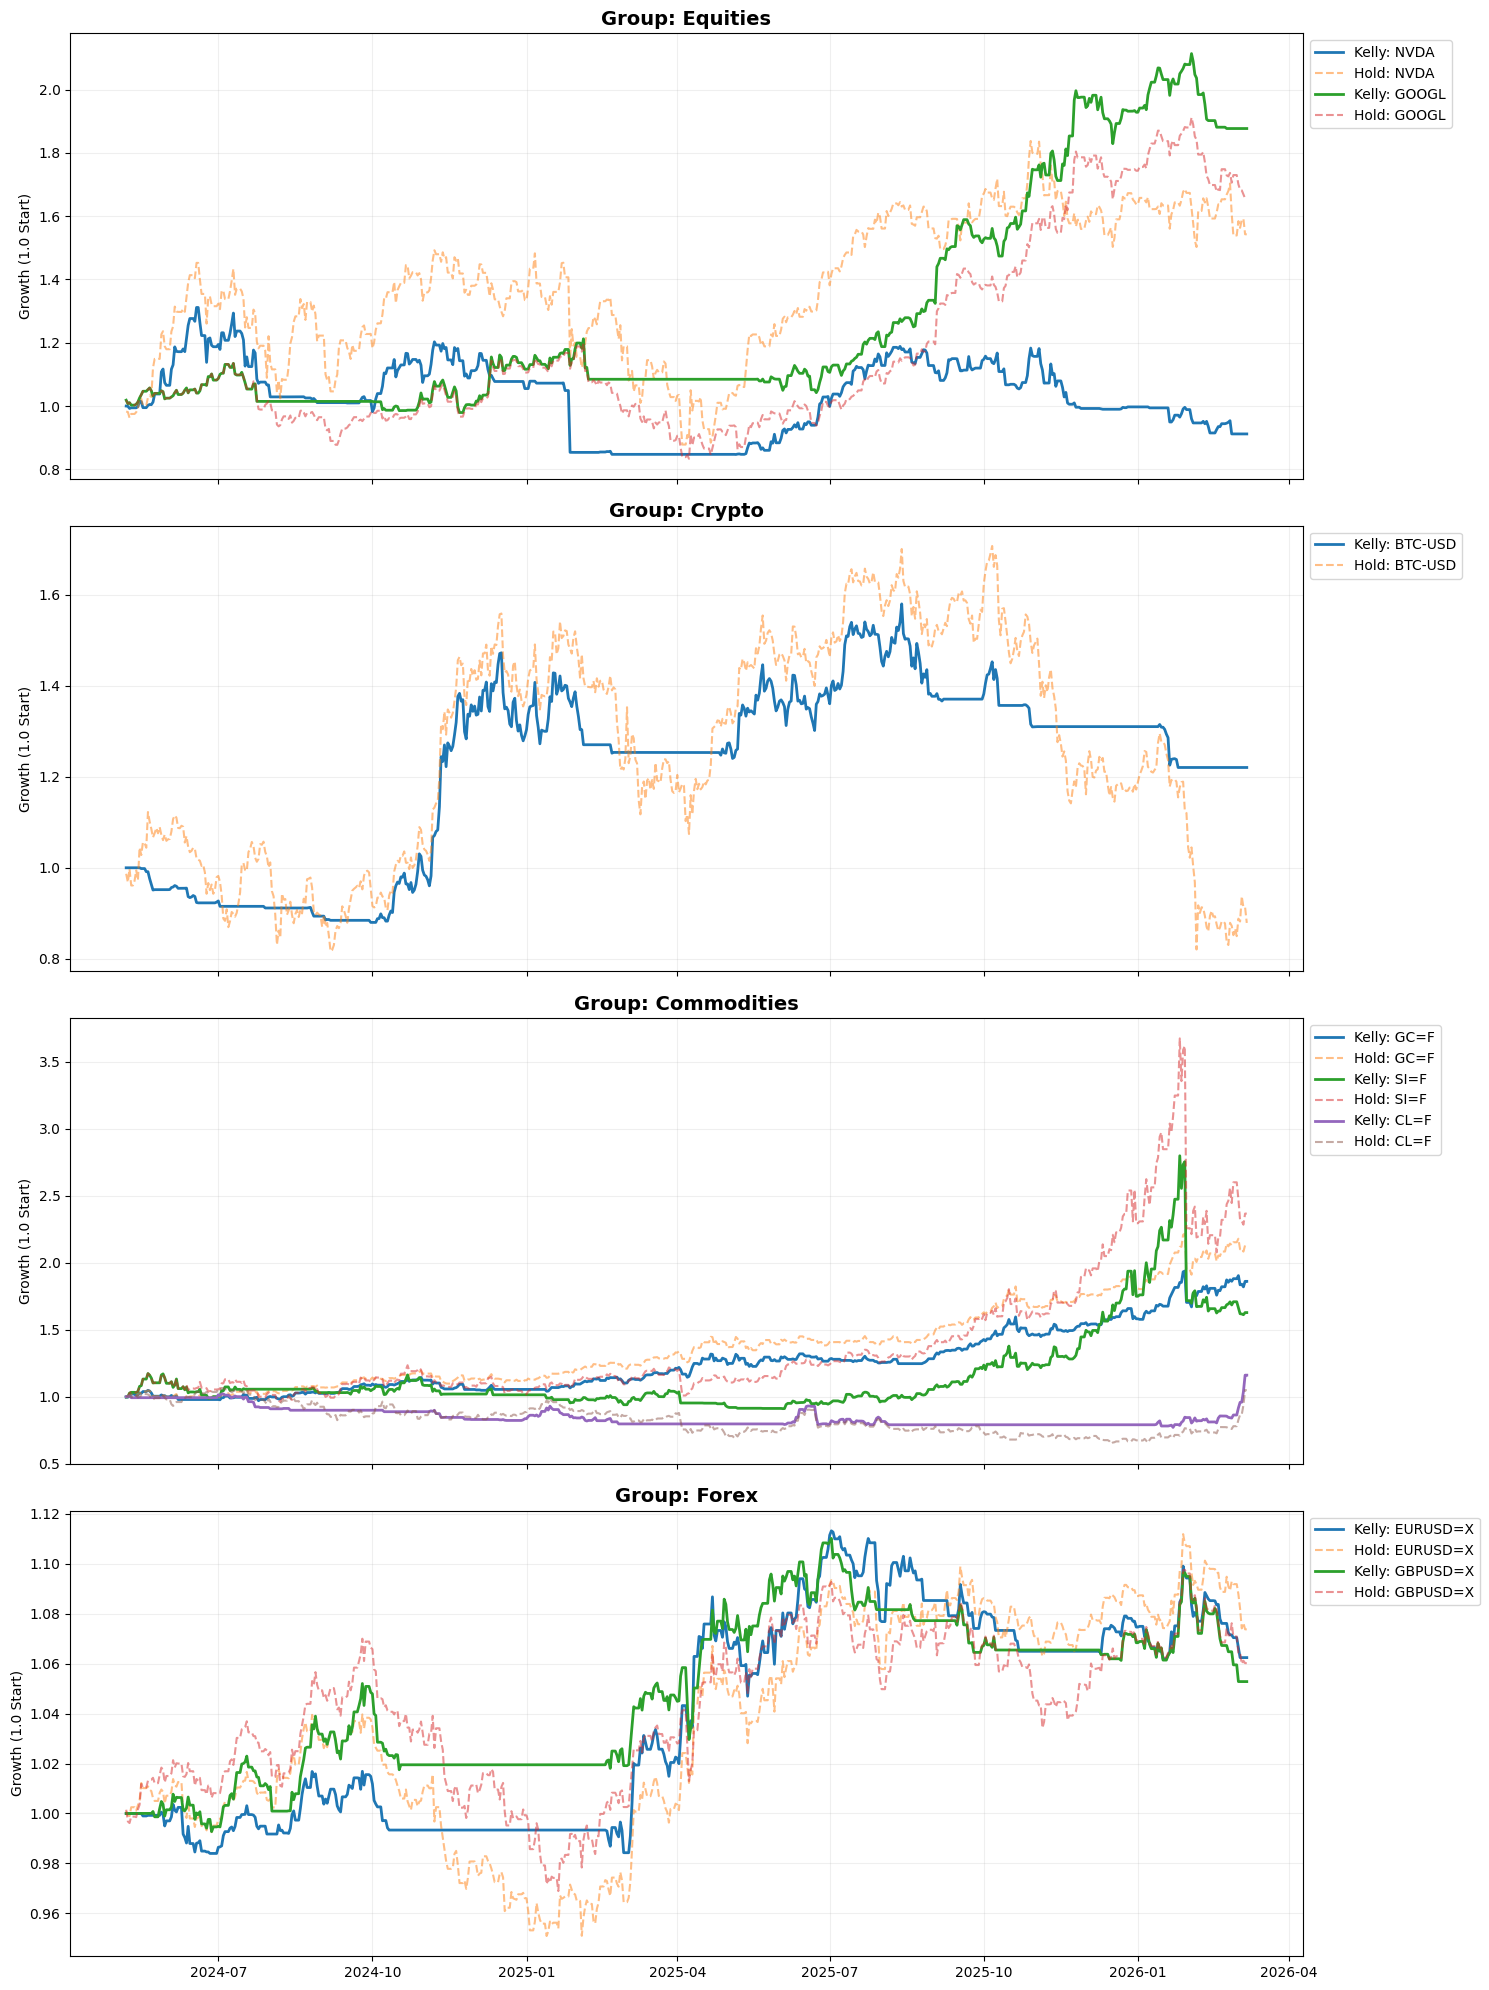


--- Final Performance Summary (Net of Costs) ---
                   Ann_Return    Sharpe    Max_DD
Asset    Strat                                   
NVDA     Kelly      -0.034090 -0.134035 -0.354134
         Buy&Hold    0.177111  0.432477 -0.411434
GOOGL    Kelly       0.267179  1.405800 -0.140310
         Buy&Hold    0.208891  0.865143 -0.306400
BTC-USD  Kelly       0.077745  0.369991 -0.227476
         Buy&Hold   -0.047391 -0.120136 -0.519214
GC=F     Kelly       0.263188  1.461995 -0.138117
         Buy&Hold    0.329108  1.782199 -0.137874
SI=F     Kelly       0.201184  0.525747 -0.423931
         Buy&Hold    0.382753  0.895575 -0.434672
CL=F     Kelly       0.057687  0.317881 -0.244695
         Buy&Hold    0.018150  0.065056 -0.389543
EURUSD=X Kelly       0.023029  0.458251 -0.046041
         Buy&Hold    0.027117  0.446079 -0.085324
GBPUSD=X Kelly       0.019543  0.439523 -0.051644
         Buy&Hold    0.022226  0.377128 -0.094424


In [14]:


# 1. กำหนดรายชื่อสินทรัพย์ทั้งหมด
all_assets = {
    'Equities': ['NVDA', 'GOOGL'],
    'Crypto': ['BTC-USD'],
    'Commodities': ['GC=F', 'SI=F', 'CL=F'],
    'Forex': ['EURUSD=X', 'GBPUSD=X']
}

# 2. ตั้งค่า Transaction Cost (เช่น 0.1% ต่อการปรับพอร์ต)
comm_rate = 0.001

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 20), sharex=True)
asset_list = [item for sublist in all_assets.values() for item in sublist]

# Helper function to calculate Max Drawdown
def calculate_max_drawdown(cumulative_returns):
    if cumulative_returns.empty:
        return 0
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

metrics_summary = []

for idx, (group_name, tickers_in_group) in enumerate(all_assets.items()): # Renamed 'tickers' to 'tickers_in_group' to avoid shadowing
    for ticker in tickers_in_group:
        # Ensure 'returns' and 'portfolio_returns' contain the ticker data
        if ticker not in portfolio_returns.columns or ticker not in returns.columns:
            print(f"Warning: Data for {ticker} not found in portfolio_returns or returns. Skipping.")
            continue

        # Calculate Cumulative Returns of Kelly (Net of Costs)
        kelly_net_returns = portfolio_returns[ticker] - (abs(portfolio_returns[ticker].diff()) * comm_rate).fillna(0)
        kelly_cum = (1 + kelly_net_returns).cumprod()

        # Benchmark: Buy & Hold
        benchmark_cum = (1 + returns[ticker].iloc[window:]).cumprod()

        # Plotting
        axes[idx].plot(kelly_cum, label=f'Kelly: {ticker}', lw=2)
        axes[idx].plot(benchmark_cum, label=f'Hold: {ticker}', linestyle='--', alpha=0.5)

        # Calculate performance metrics for Kelly Strategy
        kelly_ann_return = (kelly_cum.iloc[-1] ** (252 / len(kelly_cum))) - 1 if len(kelly_cum) > 0 else 0
        kelly_ann_vol = kelly_net_returns.std() * np.sqrt(252) if len(kelly_net_returns) > 1 else 0
        kelly_sharpe = kelly_ann_return / kelly_ann_vol if kelly_ann_vol > 0 else 0
        kelly_max_dd = calculate_max_drawdown(kelly_cum)

        # Calculate performance metrics for Buy & Hold
        bh_ann_return = (benchmark_cum.iloc[-1] ** (252 / len(benchmark_cum))) - 1 if len(benchmark_cum) > 0 else 0
        bh_ann_vol = returns[ticker].iloc[window:].std() * np.sqrt(252) if len(returns[ticker].iloc[window:]) > 1 else 0
        bh_sharpe = bh_ann_return / bh_ann_vol if bh_ann_vol > 0 else 0
        bh_max_dd = calculate_max_drawdown(benchmark_cum)

        metrics_summary.append({
            'Asset': ticker,
            'Strat': 'Kelly',
            'Ann_Return': kelly_ann_return,
            'Sharpe': kelly_sharpe,
            'Max_DD': kelly_max_dd
        })
        metrics_summary.append({
            'Asset': ticker,
            'Strat': 'Buy&Hold',
            'Ann_Return': bh_ann_return,
            'Sharpe': bh_sharpe,
            'Max_DD': bh_max_dd
        })

    axes[idx].set_title(f"Group: {group_name}", fontsize=14, fontweight='bold')
    axes[idx].set_ylabel("Growth (1.0 Start)")
    axes[idx].legend(loc='upper left', bbox_to_anchor=(1, 1))
    axes[idx].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# สรุปผล Metrics ทั้งหมด
print("\n--- Final Performance Summary (Net of Costs) ---")
df_metrics = pd.DataFrame(metrics_summary).set_index(['Asset', 'Strat'])
print(df_metrics.loc[asset_list])

In [20]:
!pip install arch

/tmp/ipykernel_386/265403862.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers_list, period="2y")['Close'].ffill()
[*********************100%***********************]  8 of 8 completed


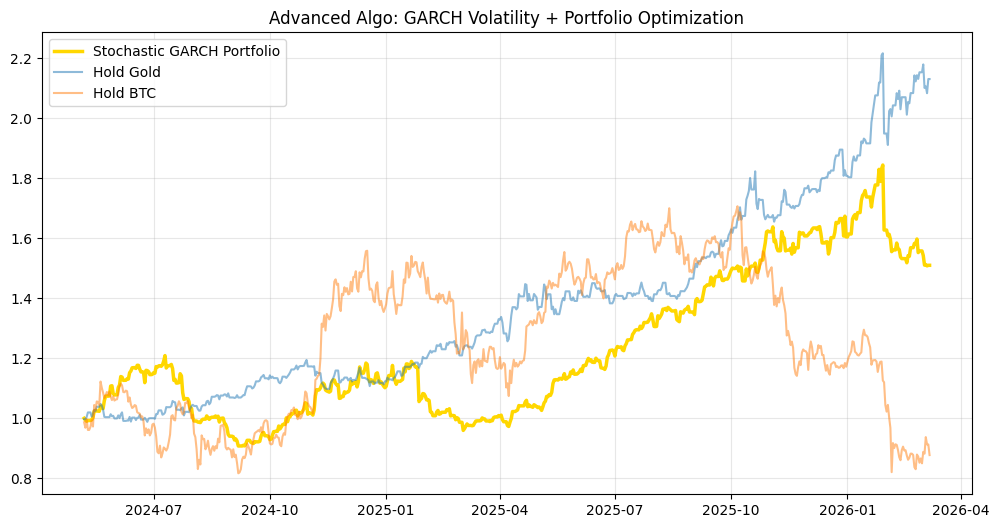

In [26]:

from arch import arch_model  # ต้องติดตั้ง: pip install arch
from scipy.optimize import minimize

# 1. เตรียมข้อมูล
tickers_list = ['GC=F', 'SI=F', 'CL=F', 'NVDA', 'GOOGL', 'EURUSD=X', 'GBPUSD=X', 'BTC-USD']
data = yf.download(tickers_list, period="2y")['Close'].ffill()
returns = np.log(data / data.shift(1)).dropna()

# 2. ฟังก์ชันพยากรณ์ความผันผวนด้วย GARCH(1,1)

def forecast_volatility_garch(asset_returns):
    # ลบพารามิเตอร์ที่ไม่จำเป็นออกให้หมด เหลือแค่ข้อมูลหลัก
    model = arch_model(asset_returns * 100, vol='Garch', p=1, q=1, dist='Normal', rescale=False)

    # ใช้แค่ disp='off' เพื่อไม่ให้มัน Print ขั้นตอนการคำนวณออกมาเต็มหน้าจอ
    res = model.fit(disp='off')

    forecast = res.forecast(horizon=1)

    # ดึงค่าพยากรณ์ความผันผวนออกมา
    return np.sqrt(forecast.variance.values[-1, 0]) / 100



# 3. เริ่มทำ Rolling Portfolio Optimization
window = 60
portfolio_value = [1.0] # เริ่มต้นที่ 1.0
dates = returns.index[window:]

for i in range(window, len(returns)):
    # หั่นข้อมูลย้อนหลัง
    slice_df = returns.iloc[i-window:i]

    # ก้าวที่ 1: พยากรณ์ Sigma รายตัวด้วย GARCH
    vols = np.array([forecast_volatility_garch(slice_df[t]) for t in tickers_list])

    # ก้าวที่ 2: หา Correlation Matrix และสร้าง Covariance Matrix พยากรณ์
    corr_matrix = slice_df.corr().values
    # Cov = Diag(Vols) * Corr * Diag(Vols)
    cov_matrix = np.outer(vols, vols) * corr_matrix

    # ก้าวที่ 3: คำนวณ Drift (Mu)
    mu_vec = slice_df.mean().values

    # ก้าวที่ 4: Optimization (Maximize Sharpe / Kelly Objective)
    def objective(w):
        port_return = np.sum(mu_vec * w)
        port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
        if port_vol == 0: return 0
        return - (port_return / port_vol) # Negative Sharpe สำหรับ Minimize

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0}) # รวมน้ำหนัก = 100%
    bounds = tuple((0, 0.4) for _ in range(len(tickers_list))) # จำกัดลงตัวละไม่เกิน 40% เพื่อกระจายความเสี่ยง

    res = minimize(objective, [1/len(tickers_list)]*len(tickers_list), bounds=bounds, constraints=constraints)
    weights = res.x

    # ก้าวที่ 5: คำนวณผลตอบแทนพอร์ตวันถัดไป
    actual_returns = returns.iloc[i].values
    daily_port_return = np.sum(weights * actual_returns)
    portfolio_value.append(portfolio_value[-1] * (1 + daily_port_return))

# 4. พล็อตผลลัพธ์เทียบกับ Benchmark (S&P 500 หรือ Gold)
plt.figure(figsize=(12, 6))
plt.plot(dates, portfolio_value[1:], label='Stochastic GARCH Portfolio', color='gold', lw=2.5)
plt.plot(dates, (1 + returns['GC=F'].iloc[window:]).cumprod(), label='Hold Gold', alpha=0.5)
plt.plot(dates, (1 + returns['BTC-USD'].iloc[window:]).cumprod(), label='Hold BTC', alpha=0.5)

plt.title("Advanced Algo: GARCH Volatility + Portfolio Optimization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
